<a href="https://colab.research.google.com/github/rifkiylndra/deepfake-detection/blob/main/deepfake_detection_cnn_attention_efficientNet80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Setup Lingkungan & Konfigurasi (Infrastructure)

In [ ]:
import os
import shutil
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers, mixed_precision
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight
from tqdm.notebook import tqdm


CONFIG = {
    "IMG_SIZE": (128, 128),    # Ukuran kecil agar training cepat di Colab
    "BATCH_SIZE": 128,       # Manfaatkan VRAM T4 GPU
    "EPOCHS": 35,            # Jumlah epoch per eksperimen
    "LEARNING_RATE": 0.001,  # LR Default
    "SEED": 42,
    "VAL_SPLIT": 0.2,        # 20% data untuk validasi
}

In [ ]:
# --- 1.3 Optimisasi Hardware (Mixed Precision) ---
# Ini membuat training di GPU T4 2x-3x lebih cepat
try:
    mixed_precision.set_global_policy('mixed_float16')
    print("✅ Mixed Precision Diaktifkan (Training akan lebih cepat)")
except Exception as e:
    print("⚠️ Mixed Precision gagal:", e)

✅ Mixed Precision Diaktifkan (Training akan lebih cepat)


In [ ]:
# --- 1.4 Download Dataset ---
print("⬇️ Sedang mendownload dataset...")
path = kagglehub.dataset_download("reubensuju/celeb-df-v2")
print("✅ Dataset Path:", path)

# Definisikan path folder video
REAL_DIR = os.path.join(path, "Celeb-real")
FAKE_DIR = os.path.join(path, "Celeb-synthesis")
YOUTUBE_REAL_DIR = os.path.join(path, "YouTube-real")
OUTPUT_DIR = "frames_dataset" # Folder tujuan frame

⬇️ Sedang mendownload dataset...


100%|██████████| 9.29G/9.29G [07:01<00:00, 23.7MB/s]

Extracting files...


✅ Dataset Path: /root/.cache/kagglehub/datasets/reubensuju/celeb-df-v2/versions/1


# 2. Data Engineering (Pipeline)

In [ ]:
# --- 2.1 Fungsi Ekstraksi Frame (Efisien) ---
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def extract_frames_smart(video_dir, label, max_frames=10, max_videos=None):
    """
    Mengekstrak frame secara merata dari video.
    max_videos: Batasi jumlah video jika ingin testing cepat (misal: 500). Set None untuk semua.
    """
    save_path = os.path.join(OUTPUT_DIR, label)
    os.makedirs(save_path, exist_ok=True)

    # Cek apakah folder sumber ada isinya
    if not os.path.exists(video_dir):
        print(f"⚠️ Folder {video_dir} tidak ditemukan! Skip.")
        return

    videos = os.listdir(video_dir)
    if len(videos) == 0:
        print(f"⚠️ Tidak ada video di {video_dir}! Skip.")
        return

    if max_videos:
        videos = videos[:max_videos]

    print(f"⚙️ Memproses {len(videos)} video dari {label}...")

    count_total = 0
    # for video_file in videos:
    for video_file in tqdm(videos, desc=f"Processing {label}", unit="vid"):
        video_path = os.path.join(video_dir, video_file)
        cap = cv2.VideoCapture(video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        if total_frames <= 0: continue

        # Ambil frame di interval tertentu (bukan 10 frame pertama saja, tapi tersebar)
        interval = max(1, total_frames // max_frames)

        for i in range(0, total_frames, interval):
            if i >= total_frames: break
            cap.set(cv2.CAP_PROP_POS_FRAMES, i)
            ret, frame = cap.read()

            if ret:
                final_img = None

                # A. Coba Deteksi Wajah
                try:
                    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
                    faces = face_cascade.detectMultiScale(gray, 1.1, 4)

                    if len(faces) > 0:
                        # Ambil wajah terbesar
                        faces = sorted(faces, key=lambda x: x[2]*x[3], reverse=True)
                        x, y, w, h = faces[0]

                        # Padding
                        padding = int(w * 0.1)
                        y1 = max(0, y - padding)
                        y2 = min(frame.shape[0], y + h + padding)
                        x1 = max(0, x - padding)
                        x2 = min(frame.shape[1], x + w + padding)

                        face_crop = frame[y1:y2, x1:x2]
                        final_img = cv2.resize(face_crop, CONFIG["IMG_SIZE"])
                except:
                    pass

                # B. Fallback (Jika wajah gagal dideteksi, pakai Full Frame)
                if final_img is None:
                    try:
                        final_img = cv2.resize(frame, CONFIG["IMG_SIZE"])
                    except:
                        continue # Skip jika frame rusak total

                # C. Simpan
                if final_img is not None:
                    fname = f"{os.path.splitext(video_file)[0]}_{i}.jpg"
                    cv2.imwrite(os.path.join(save_path, fname), final_img)
                    count_total += 1

            if len(os.listdir(save_path)) >= (len(videos) * max_frames): break
        cap.release()

    print(f"✅ Selesai {label}: {count_total} frames tersimpan.")
    # print(f"✅ Selesai ekstraksi {label}: {count_total} frames.")
    # print(f"✅ Selesai. Total Wajah di '{label}': {count_total}")

# --- 3. EKSEKUSI ULANG ---
if os.path.exists(OUTPUT_DIR):
    print("🗑️ Membersihkan dataset lama...")
    shutil.rmtree(OUTPUT_DIR)

print("🚀 Memulai Ekstraksi Hybrid (Face Crop + Full Frame)...")

# Pastikan variabel path ini benar (dari cell 1)
print(f"📂 Source Real: {REAL_DIR}")
print(f"📂 Source Fake: {FAKE_DIR}")

extract_frames_smart(REAL_DIR, "real", max_frames=10, max_videos=None)
extract_frames_smart(YOUTUBE_REAL_DIR, "real", max_frames=10, max_videos=None)
extract_frames_smart(FAKE_DIR, "fake", max_frames=10, max_videos=900)

# Verifikasi akhir
num_real = len(os.listdir(os.path.join(OUTPUT_DIR, "real")))
num_fake = len(os.listdir(os.path.join(OUTPUT_DIR, "fake")))
print(f"\n📊 Total Data Tersimpan: Real={num_real}, Fake={num_fake}")

🚀 Memulai Ekstraksi Hybrid (Face Crop + Full Frame)...
📂 Source Real: /root/.cache/kagglehub/datasets/reubensuju/celeb-df-v2/versions/1/Celeb-real
📂 Source Fake: /root/.cache/kagglehub/datasets/reubensuju/celeb-df-v2/versions/1/Celeb-synthesis
⚙️ Memproses 590 video dari real...


Processing real:   0%|          | 0/590 [00:00<?, ?vid/s]

✅ Selesai real: 5947 frames tersimpan.
⚙️ Memproses 300 video dari real...


Processing real:   0%|          | 0/300 [00:00<?, ?vid/s]

✅ Selesai real: 300 frames tersimpan.
⚙️ Memproses 900 video dari fake...


Processing fake:   0%|          | 0/900 [00:00<?, ?vid/s]

✅ Selesai fake: 9075 frames tersimpan.

📊 Total Data Tersimpan: Real=6247, Fake=9075


In [ ]:
# --- 2.2 Membangun tf.data Pipeline (High Performance) ---
print("\n🚀 Membangun Data Pipeline...")

# Load Dataset (Train & Val)
train_ds = tf.keras.utils.image_dataset_from_directory(
    OUTPUT_DIR,
    validation_split=CONFIG["VAL_SPLIT"],
    subset="training",
    seed=CONFIG["SEED"],
    image_size=CONFIG["IMG_SIZE"],
    batch_size=CONFIG["BATCH_SIZE"],
    label_mode='binary'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    OUTPUT_DIR,
    validation_split=CONFIG["VAL_SPLIT"],
    subset="validation",
    seed=CONFIG["SEED"],
    image_size=CONFIG["IMG_SIZE"],
    batch_size=CONFIG["BATCH_SIZE"],
    label_mode='binary'
)

# (Opsional) Pisahkan Validation jadi Val & Test
val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batches // 2) # 50% dari val jadi Test
val_ds = val_ds.skip(val_batches // 2)  # Sisanya tetap Val


🚀 Membangun Data Pipeline...
Found 15322 files belonging to 2 classes.
Using 12258 files for training.
Found 15322 files belonging to 2 classes.
Using 3064 files for validation.


In [ ]:
# --- 2.3 Augmentasi & Optimasi ---
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1)
])

def preprocess(image, label):
    image = tf.cast(image, tf.float32)  # / 255.0 # Normalisasi
    return image, label

AUTOTUNE = tf.data.AUTOTUNE

# Pipeline Training (Augmentasi + Cache + Prefetch)
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(preprocess, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

# Pipeline Val & Test (Hanya Preprocess + Cache)
val_ds = val_ds.map(preprocess, num_parallel_calls=AUTOTUNE).cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.map(preprocess, num_parallel_calls=AUTOTUNE).cache().prefetch(buffer_size=AUTOTUNE)

print("✅ Pipeline Siap! Data mengalir cepat ke GPU.")

✅ Pipeline Siap! Data mengalir cepat ke GPU.


# 3. Model Engineering

In [ ]:
# --- 3.1 Modul CBAM (Attention) ---
def cbam_block(feature_map, ratio=8):
    """Modul atensi untuk fokus pada fitur penting"""
    channel = feature_map.shape[-1]

    # Channel Attention
    avg_pool = layers.GlobalAveragePooling2D()(feature_map)
    max_pool = layers.GlobalMaxPooling2D()(feature_map)

    shared_dense1 = layers.Dense(channel // ratio, activation='relu', kernel_initializer='he_normal', use_bias=True, bias_initializer='zeros')
    shared_dense2 = layers.Dense(channel, activation='sigmoid', kernel_initializer='he_normal', use_bias=True, bias_initializer='zeros')

    avg_out = shared_dense2(shared_dense1(avg_pool))
    max_out = shared_dense2(shared_dense1(max_pool))

    channel_attention = layers.Add()([avg_out, max_out])
    channel_attention = layers.Activation('sigmoid')(channel_attention)
    channel_attention = layers.Reshape((1, 1, channel))(channel_attention)
    x = layers.Multiply()([feature_map, channel_attention])

    # Spatial Attention
    avg_pool_s = layers.Lambda(lambda z: tf.reduce_mean(z, axis=3, keepdims=True))(x)
    max_pool_s = layers.Lambda(lambda z: tf.reduce_max(z, axis=3, keepdims=True))(x)

    concat = layers.Concatenate(axis=3)([avg_pool_s, max_pool_s])
    spatial_attention = layers.Conv2D(1, (7, 7), padding='same', activation='sigmoid')(concat)

    return layers.Multiply()([x, spatial_attention])



In [ ]:
# --- 3.2 Arsitektur Model Transfer Learning (EfficientNetB0 + CBAM) ---
from tensorflow.keras.applications import EfficientNetB0

def build_transfer_model(learning_rate=0.00001):

    # Input Layer
    inputs = layers.Input(shape=CONFIG["IMG_SIZE"] + (3,))

    # 1. Base Model (EfficientNetB0)
    # Menggunakan bobot 'imagenet' yang sudah terlatih
    base_model = EfficientNetB0(
        include_top=False,
        # include_top=True,
        weights='imagenet',
        input_shape=CONFIG["IMG_SIZE"] + (3,)
    )

    # Bekukan bobot base model (Frozen) agar tidak rusak saat training awal
    # base_model.trainable = False

    # --- PERUBAHAN UTAMA: UNFREEZE ---
    # Kita izinkan model untuk belajar (update bobot)
    base_model.trainable = True

    # TAPI, kita bekukan sebagian besar layer awal (fitur dasar seperti garis/sudut)
    # Kita hanya melatih 20-30 layer terakhir (fitur kompleks seperti mata/mulut)
    for layer in base_model.layers[:-30]:
        layer.trainable = False

    # Ambil output dari EfficientNet
    x = base_model(inputs)

    # 2. Sisipkan Modul CBAM (Attention)
    # Ini akan membantu model fokus pada fitur wajah yang penting
    x = cbam_block(x)

    # # 3. Classifier Head (Bagian Klasifikasi)
    # x = layers.GlobalAveragePooling2D()(x) # Meratakan fitur
    # x = layers.BatchNormalization()(x)     # Menstabilkan training
    # x = layers.Dropout(0.5)(x)             # Mencegah overfitting

    # 3. Classifier Head (Diperkuat Regularisasinya)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)

    # Tambah Dense layer ekstra untuk transisi
    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.Dropout(0.6)(x) # Dropout diperbesar

    # Output Layer (Binary Classification: 0=Fake, 1=Real)
    outputs = layers.Dense(1, activation='sigmoid', dtype='float32')(x)

    # Gabungkan menjadi Model
    model = models.Model(inputs, outputs, name="EfficientNet_CBAM")
    # model = models.Model(inputs, outputs, name="EfficientNet_FineTuned")

    # Compile Model
    # Learning rate kecil (0.0001) sangat disarankan untuk Transfer Learning
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

print("✅ Fungsi Model Transfer Learning (EfficientNet) Siap!")
model_transfer = build_transfer_model(learning_rate=0.00001)
print("\n📊 Tabel Arsitektur Model:")
model_transfer.summary()

✅ Fungsi Model Transfer Learning (EfficientNet) Siap!
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

📊 Tabel Arsitektur Model:


Model: "EfficientNet_CBAM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 4, 4,      │  4,049,571 │ input_layer_1[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 160)       │    204,960 │ global_average_p… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1280)      │    206,080 │ dense[0][0],      │
│                     │                   │            │ dense[1][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1280)      │          0 │ dense_1[0][0],    │
│                     │                   │            │ dense_1[1][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1280)      │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1,      │          0 │ activation[0][0]  │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 4, 4,      │          0 │ efficientnetb0[0… │
│                     │ 1280)             │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 4, 4, 1)   │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 4, 4, 1)   │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 4, 4, 2)   │          0 │ lambda[0][0],     │
│ (Concatenate)       │                   │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 4, 4, 1)   │         99 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 4, 4,      │          0 │ multiply[0][0],   │
│ (Multiply)          │ 1280)             │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ multiply_1[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1280)      │      5,120 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │    163,968 │ batch_normalizat

 Total params: 4,629,927 (17.66 MB)

 Trainable params: 2,073,956 (7.91 MB)

 Non-trainable params: 2,555,971 (9.75 MB)

# 4. Eksperimen & Pelatihan (TRANSFER LEARNING)

In [ ]:

# --- A. Hitung Class Weights (Wajib untuk Dataset Imbalance) ---
print("⚖️ Sedang menghitung bobot kelas (Class Weights)...")
print("   (Mohon tunggu, sedang membaca dataset...)")

# Kita ambil label dari dataset training untuk dihitung
y_train_labels = []
# Loop dataset train untuk mengambil label saja
for images, labels in train_ds:
    y_train_labels.extend(labels.numpy())

y_train_labels = np.array(y_train_labels).flatten()

# Hitung bobot penyeimbang
class_weights_val = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weights_dict = dict(enumerate(class_weights_val))

print(f"✅ Bobot Ditemukan: {class_weights_dict}")
print(f"   (Model akan lebih fokus pada kelas Real dengan bobot {class_weights_dict[1]:.2f})")





⚖️ Sedang menghitung bobot kelas (Class Weights)...
   (Mohon tunggu, sedang membaca dataset...)
✅ Bobot Ditemukan: {0: np.float64(0.8408560845109069), 1: np.float64(1.2334473737170457)}
   (Model akan lebih fokus pada kelas Real dengan bobot 1.23)


In [ ]:
# --- B. Setup Callbacks (Pengaman Training) ---
my_callbacks = [
    # 1. Simpan model terbaik saja (berdasarkan Val Loss)
    callbacks.ModelCheckpoint(
        'best_model_efficientnet.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    # 2. Berhenti jika tidak ada perkembangan (Hemat waktu)
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    # 3. Turunkan Learning Rate jika macet (Bantu model belajar lebih detail)
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]


In [ ]:
# --- C. Inisialisasi & Training ---
# Bersihkan memori dulu
if 'model_transfer' in globals(): del model_transfer
if 'model_cbam' in globals(): del model_cbam
tf.keras.backend.clear_session()

print("\n🚀 Menginisialisasi Model EfficientNetB0 + CBAM...")
# Panggil fungsi Transfer Learning yang baru
model_transfer = build_transfer_model(learning_rate=0.001)

print("\n🔥 MULAI TRAINING TRANSFER LEARNING...")
history_transfer = model_transfer.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CONFIG["EPOCHS"],  # Set epoch agak panjang, nanti EarlyStopping yang berhentikan
    class_weight=class_weights_dict, # <--- KUNCI MENAIKKAN AKURASI
    callbacks=my_callbacks,
    verbose=1
)

# Simpan history ke dictionary agar kompatibel dengan kode visualisasi (Langkah 5)
all_histories = {'EfficientNet_CBAM': history_transfer}

print("\n✅ Training Selesai! Silakan lanjut ke Evaluasi.")


🚀 Menginisialisasi Model EfficientNetB0 + CBAM...

🔥 MULAI TRAINING TRANSFER LEARNING...
Epoch 1/35
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.5922 - loss: 2.7277
Epoch 1: val_loss improved from inf to 1.60410, saving model to best_model_efficientnet.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 87s 506ms/step - accuracy: 0.5928 - loss: 2.7226 - val_accuracy: 0.5897 - val_loss: 1.6041 - learning_rate: 0.0010
Epoch 2/35
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.7945 - loss: 1.1994
Epoch 2: val_loss improved from 1.60410 to 1.03742, saving model to best_model_efficientnet.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - accuracy: 0.7946 - loss: 1.1979 - val_accuracy: 0.7493 - val_loss: 1.0374 - learning_rate: 0.0010
Epoch 3/35
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8465 - loss: 0.6649
Epoch 3: val_loss improved from 1.03742 to 0.69966, saving model to best_model_efficientnet.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.8465 - loss: 0.6643 - val_ac

# 5. Evaluasi & Laporan

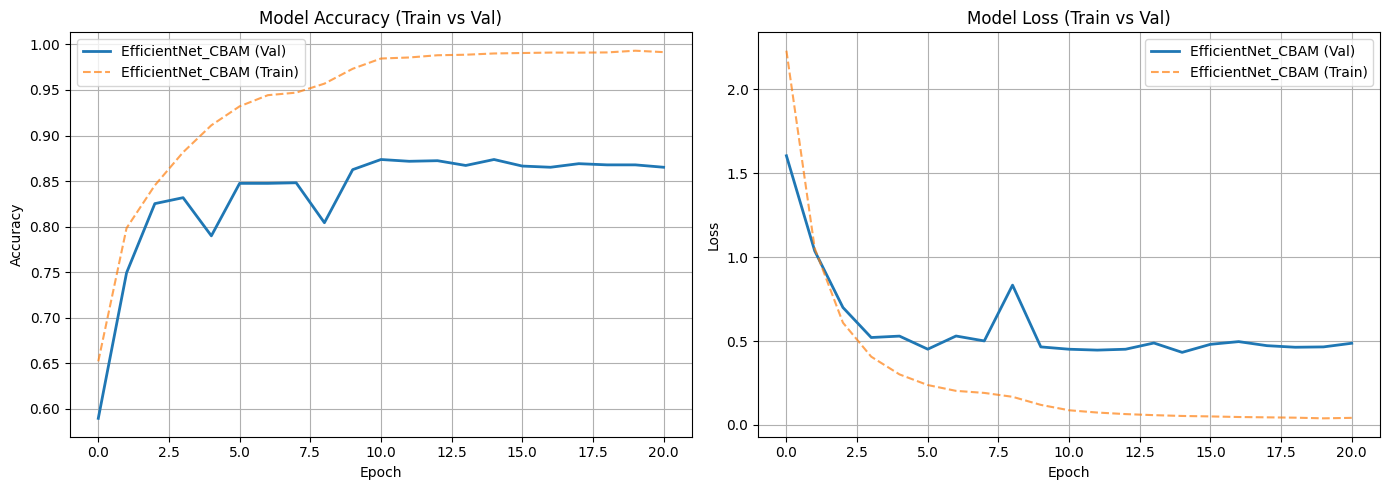

In [ ]:
# --- 5.1 Visualisasi Grafik Training (Loss & Accuracy) ---
import matplotlib.pyplot as plt

# Cek apakah history ada
if len(all_histories) == 0:
    print("⚠️ Tidak ada history pelatihan. Pastikan Training (Langkah 4) sudah selesai.")
else:
    plt.figure(figsize=(14, 5))

    # Plot Akurasi (Train vs Val)
    plt.subplot(1, 2, 1)
    for name, h in all_histories.items():
        # Garis Solid untuk Validasi (Target utama kita)
        plt.plot(h.history['val_accuracy'], label=name + ' (Val)', linewidth=2)
        # Garis Putus-putus untuk Training
        plt.plot(h.history['accuracy'], label=name + ' (Train)', linestyle='--', alpha=0.7)

    plt.title('Model Accuracy (Train vs Val)')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot Loss (Train vs Val)
    plt.subplot(1, 2, 2)
    for name, h in all_histories.items():
        plt.plot(h.history['val_loss'], label=name + ' (Val)', linewidth=2)
        plt.plot(h.history['loss'], label=name + ' (Train)', linestyle='--', alpha=0.7)

    plt.title('Model Loss (Train vs Val)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


🏆 Evaluasi Final pada Data Test...
⚠️ File model tidak ditemukan, menggunakan model terakhir dari memori.
⏳ Sedang melakukan prediksi pada data test...
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 94ms/step

 CLASSIFICATION REPORT 
              precision    recall  f1-score   support

        Fake       0.89      0.91      0.90       882
        Real       0.87      0.84      0.86       654

    accuracy                           0.88      1536
   macro avg       0.88      0.88      0.88      1536
weighted avg       0.88      0.88      0.88      1536



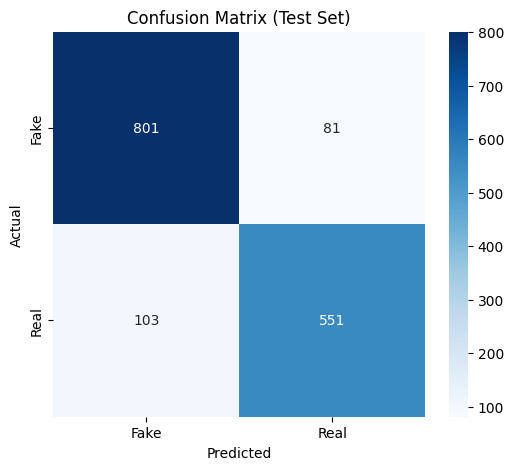

In [ ]:
# --- 5.2 Evaluasi Akhir pada Test Set (UPDATED) ---
from tensorflow.keras.models import load_model

print("\n🏆 Evaluasi Final pada Data Test...")

# 1. Load Model Terbaik
# Kita mencoba memuat model yang disimpan oleh ModelCheckpoint (akurasi/loss terbaik)
# bukan model di epoch terakhir yang mungkin sudah overfitting.
best_model_path = 'best_model_efficientnet.keras'

try:
    # Coba load dari file
    final_model = load_model(best_model_path, safe_mode=False)
    print(f"✅ Berhasil memuat model terbaik dari file: {best_model_path}")
except:
    # Jika file tidak ketemu, pakai model yang ada di memori
    print("⚠️ File model tidak ditemukan, menggunakan model terakhir dari memori.")
    final_model = model_transfer

# 2. Prediksi
print("⏳ Sedang melakukan prediksi pada data test...")
predictions = final_model.predict(test_ds)
y_pred = np.where(predictions > 0.5, 1, 0).flatten()

# 3. Ambil Label Asli (Ground Truth) dari test_ds
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# --- Laporan & Visualisasi ---
print("\n" + "="*30)
print(" CLASSIFICATION REPORT ")
print("="*30)
# Pastikan target_names sesuai urutan kelas folder Anda (biasanya Fake=0, Real=1)
print(classification_report(y_true, y_pred, target_names=['Fake', 'Real']))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title('Confusion Matrix (Test Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()